# Analisis Univariado



A continuación se procederá a examinar cada variable de forma individual con el objetivo de entender su distribución, medidas centrales y de dispersión. Para complementar el análisis utilizaremos tablas estadísticas y gráficas según se considere adecuado

## 0. Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga y Preparación de Datos


In [ ]:
filename=r"Data\diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(filename, sep=',')

df = df.rename(columns={
    'Diabetes_binary': 'Diabetes',
    'HighBP':         'PA_alta',
    'HighChol':     'col_alto',
    'CholCheck':   'CheckCol',
    'BMI':  'IMC',
    'Smoker':   'Fumador',
    'Stroke':      'derrame',
    'HeartDiseaseorAttack': 'EnfCardi',
    'PhysActivity':  'ActFisi',
    'Fruits':    'fruta',
    'Veggies':   'vegetales',
    'HvyAlcoholConsump':     'Alcohlico',
    'AnyHealthcare':        'eps',
    'NoDocbcCost':    'AfordabilidadMedica',
    'GenHlth':         'SaludG',
    'MentHlth':        'SaludM',
    'PhysHlth':        'SaludF',
    'DiffWalk':        'DificultadCaminar',
    'Sex': 'Genero',
    'Age': 'Edad',
    'Education': 'Educacion',
    'Income': 'Ingresos'
})[[  
    'Diabetes', 'PA_alta', 'col_alto', 'CheckCol', 
    'IMC', 'Fumador', 'derrame', 'EnfCardi', 'ActFisi', 
    'fruta', 'vegetales', 'Alcohlico', 'eps', 'AfordabilidadMedica', 
    'SaludG', 'SaludM', 'SaludF', 'DificultadCaminar', 'Genero',
    'Edad', 'Educacion', 'Ingresos'
]]


df = df.drop_duplicates()
df.head()

## 2. Variables categoricas

### Variable Respuesta: (`Diabetes`)

**Tabla**

In [4]:
tabla_y = (
    df['Diabetes']
    .value_counts()
    .reset_index()
    .rename(columns={'Diabetes': 'Diabetes', 'count': 'Frecuencia'})
)

tabla_y['Porcentaje'] = (tabla_y['Frecuencia'] / tabla_y['Frecuencia'].sum() * 100).round(1)

tabla_y

,Diabetes,Frecuencia,Porcentaje
0,1.0,35097,50.8
1,0.0,33960,49.2


Como podemos observar, dado que el archivo es el conjunto de datos con la división 50/50 (5050split), la clase está perfectamente balanceada con exactamente la misma cantidad de registros para pacientes con y sin diabetes.

**Grafico** 

In [ ]:


plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df, x='Diabetes', palette=['#4C72B0', '#DD8452'])

plt.title('Distribución de la variable Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0.0\n(No Diabetes)', '1.0\n(Prediabetes / Diabetes)'])


for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

Este gráfico muestra la distribución de los pacientes con y sin diabetes, confirmando que tiene distribucion igual.

 (`PA_alta`): Corresponde a la variable que nos dice si el paciente cuenta con presion arterial alta o no.

**Tabla** 

In [5]:

tabla_pa = (
    df['PA_alta']
    .value_counts()
    .reset_index()
    .rename(columns={'PA_alta': 'PA_alta', 'count': 'Frecuencia'})
)


tabla_pa['Porcentaje'] = (tabla_pa['Frecuencia'] / tabla_pa['Frecuencia'].sum() * 100).round(1)


tabla_pa

,PA_alta,Frecuencia,Porcentaje
0,1.0,39447,57.1
1,0.0,29610,42.9


**Grafico**

In [ ]:

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df, x='PA_alta', palette=['#55A868', '#C44E52'])

plt.title('Distribución de la variable PA_alta (Presión Arterial Alta)', fontsize=14, fontweight='bold')
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0.0\n(No)', '1.0\n(Sí)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

Como podemos observar en la tabla, el 56.3% de los participantes en esta base de datos balanceada reportan haber sido diagnosticados con presión arterial alta, mientras que el 43.7% no tienen esta condición.

(`col_alto`): Esta variable corresponde a si el paciente cuenta con un colesterol alto o no.

**Tabla**

In [6]:
tabla_col = (
    df['col_alto']
    .value_counts()
    .reset_index()
    .rename(columns={'col_alto': 'col_alto', 'count': 'Frecuencia'})
)
tabla_col['Porcentaje'] = (tabla_col['Frecuencia'] / tabla_col['Frecuencia'].sum() * 100).round(1)


print(tabla_col)

   col_alto  Frecuencia  Porcentaje
0       1.0       36692        53.1
1       0.0       32365        46.9


**Grafico**

In [ ]:
plt.figure(figsize=(7, 7))


colores = ['#e74c3c', '#2ecc71'] 
explode = (0.05, 0)

plt.pie(tabla_col['Frecuencia'], 
        labels=['1.0\n(Sí tiene)', '0.0\n(No tiene)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores, 
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Distribución de la variable col_alto (Colesterol Alto)', fontsize=15, fontweight='bold')
plt.axis('equal') 

plt.tight_layout()
plt.show()

La tabla indica que hay una proporción ligeramente mayor de personas diagnosticadas con colesterol alto (52.6%) en comparación con aquellas que no lo padecen (47.4%).

(`CheckCol`): Esta variable nos dice si el paciente se realizo examenes que chequeen su colesterol en los ultimos 5 años. 

**Tabla**

In [ ]:
tabla_checkcol = (
    df['CheckCol']
    .value_counts()
    .reset_index()
    .rename(columns={'CheckCol': 'CheckCol', 'count': 'Frecuencia'})
)
tabla_checkcol['Porcentaje'] = (tabla_checkcol['Frecuencia'] / tabla_checkcol['Frecuencia'].sum() * 100).round(1)
print(tabla_checkcol)

**Grafico**

In [ ]:
plt.figure(figsize=(7, 7))
colores = ['#3498db', '#e67e22'] 

plt.pie(tabla_checkcol['Frecuencia'], 
        labels=['1.0\n(Sí se chequeó)', '0.0\n(No se chequeó)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores, 
        pctdistance=0.75, 
        textprops={'fontsize': 12})

centro_circulo = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Distribución de la variable CheckCol\n(Chequeo de Colesterol en últimos 5 años)', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

Como podemos observar, la inmensa mayoría de las personas en esta base de datos (97.5%) sí se han realizado un chequeo de colesterol recientemente, mientras que solamente el 2.5% no se ha chequeado en los ultimos 5 años. 


(`Fumador`): Nos dice si el paciente fuma o no. 

**Tabla**

In [ ]:
tabla_fumador = (
    df['Fumador']
    .value_counts()
    .reset_index()
    .rename(columns={'Fumador': 'Fumador', 'count': 'Frecuencia'})
)
tabla_fumador['Porcentaje'] = (tabla_fumador['Frecuencia'] / tabla_fumador['Frecuencia'].sum() * 100).round(1)


print(tabla_fumador)

**Grafica**

In [ ]:
fumador_counts = df['Fumador'].value_counts()
fumador_percentages = (fumador_counts / fumador_counts.sum() * 100).round(1)

lolipop_df = pd.DataFrame({
    'Category': ['No fumador', 'Fumador'],
    'Value': fumador_counts.values,
    'Percentage': fumador_percentages.values
})

lolipop_df = lolipop_df.sort_values(by='Value', ascending=True)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.hlines(y=lolipop_df['Category'], xmin=0, xmax=lolipop_df['Value'], color='#34495e', alpha=0.7, linewidth=3)

plt.scatter(lolipop_df['Value'], lolipop_df['Category'], color=['#e74c3c', '#a1d99b'][::-1], s=200, alpha=1)

for idx, row in lolipop_df.iterrows():
    plt.annotate(f"{int(row['Value']):,}\n({row['Percentage']}%)",
                (row['Value'], row['Category']),
                ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points',
                fontsize=11, color='black', fontweight='bold')

plt.title('Distribución de la variable Fumador (Gráfico de Piruleta)', fontsize=15, fontweight='bold')
plt.xlabel('Frecuencia (Número de personas)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

plt.xlim(0, lolipop_df['Value'].max() * 1.1)

plt.tight_layout()
plt.show()

Como podemos observar en la tabla, la muestra está bastante equilibrada en cuanto al tabaquismo. El 52.5% de las personas reportan no ser fumadores (según la definición de la encuesta de menos de 100 cigarrillos en su vida), mientras que un 47.5% sí clasifica como fumador.

(`derrame`): Nos dice si el paciente sufrio de un derrame cerebral o no. 

**Tabla**

In [ ]:
tabla_derrame = (
    df['derrame']
    .value_counts()
    .reset_index()
    .rename(columns={'derrame': 'derrame', 'count': 'Frecuencia'})
)
tabla_derrame['Porcentaje'] = (tabla_derrame['Frecuencia'] / tabla_derrame['Frecuencia'].sum() * 100).round(1)

print(tabla_derrame)

**Grafico**

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df, x='derrame', palette=['#4C72B0', '#DD8452'])

plt.title('Distribución de la variable derrame (Derrame Cerebral)', fontsize=16, fontweight='bold')
plt.xlabel('Derrame Cerebral', fontsize=14)
plt.ylabel('Frecuencia (Número de personas)', fontsize=14)

plt.xticks(ticks=[0, 1], labels=['0.0\n(No ha tenido)', '1.0\n(Sí ha tenido)'], fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

Como podemos ver, la gran mayoría de los pacientes en esta base de datos (93.8%) no han reportado haber sufrido un derrame cerebral, mientras que una pequeña minoría (6.2%) sí lo ha padecido.

(`EnfCardi`)EnfCardi: Dice si el paciente padece de una enfermedad cardiaca o no. 

**Tabla**

In [ ]:
tabla_enfcardi = (
    df['EnfCardi']
    .value_counts()
    .reset_index()
    .rename(columns={'EnfCardi': 'EnfCardi', 'count': 'Frecuencia'})
)
tabla_enfcardi['Porcentaje'] = (tabla_enfcardi['Frecuencia'] / tabla_enfcardi['Frecuencia'].sum() * 100).round(1)

print(tabla_enfcardi)


**Grafico**

In [ ]:
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=tabla_enfcardi, x='Frecuencia', y='EnfCardi', orient='h', 
                 palette=['#3498db', '#e74c3c'], order=[0.0, 1.0])

plt.title('Distribución de la variable EnfCardi\n(Enfermedad Cardiaca)', fontsize=15, fontweight='bold')
plt.xlabel('Frecuencia (Número de personas)', fontsize=12)
plt.ylabel('Enfermedad Cardíaca', fontsize=12)
plt.yticks(ticks=[0, 1], labels=['0.0\n(No ha tenido)', '1.0\n(Sí ha tenido)'], fontsize=11)

for i, p in enumerate(ax.patches):
    ax.annotate(f"{int(p.get_width()):,} ({tabla_enfcardi['Porcentaje'].iloc[i]}%)",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                fontsize=11, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.xlim(0, tabla_enfcardi['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

El 85.2% de las personas en esta base de datos no tiene un historial de enfermedades coronarias o ataques al corazón, mientras que el 14.8% sí reporta esta condición.

(`ActFisi`): Nos dice si el paciente ha realizado actividad fisica en los ultimops 30 dias.

**Tabla**

In [ ]:
tabla_act = (
    df['ActFisi']
    .value_counts()
    .reset_index()
    .rename(columns={'ActFisi': 'ActFisi', 'count': 'Frecuencia'})
)
tabla_act['Porcentaje'] = (tabla_act['Frecuencia'] / tabla_act['Frecuencia'].sum() * 100).round(1)

print(tabla_act)

**Grafica**

In [ ]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=tabla_act, x='ActFisi', y='Frecuencia', 
                 palette=['#2ecc71', '#e74c3c'], order=[1.0, 0.0])

plt.title('Distribución de la variable ActFisi\n(Actividad Física en los últimos 30 días)', fontsize=15, fontweight='bold')
plt.xlabel('Actividad Física', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['1.0\n(Sí realizó)', '0.0\n(No realizó)'], fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    valor_x = 1.0 if i == 0 else 0.0
    pct = tabla_act[tabla_act['ActFisi'] == valor_x]['Porcentaje'].values[0]
    
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_act['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

El 70.3% de las personas encuestadas reporta haber realizado actividad física recientemente, frente a un 29.7% que indica sedentarismo en ese periodo.

(`fruta`): Nos indica si el paciente consume frutas al manos 1 vez al dia.

**Tabla**

In [ ]:
tabla_fruta = (
    df['fruta']
    .value_counts()
    .reset_index()
    .rename(columns={'fruta': 'fruta', 'count': 'Frecuencia'})
)
tabla_fruta['Porcentaje'] = (tabla_fruta['Frecuencia'] / tabla_fruta['Frecuencia'].sum() * 100).round(1)

print(tabla_fruta)

**Grafico**

In [ ]:
plt.figure(figsize=(7, 7))
colores = ['#2ecc71', '#e74c3c'] 
explode = (0.05, 0) 

plt.pie(tabla_fruta['Frecuencia'], 
        labels=['1.0\n(Consume fruta 1+ vez al día)', '0.0\n(No consume fruta diariamente)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores, 
        explode=explode,
        shadow=True,
        textprops={'fontsize': 11})

plt.title('Distribución de la variable fruta\n(Consumo diario de fruta)', fontsize=15, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

El 61.2% de las personas encuestadas reporta consumir fruta al menos una vez al día, mientras que el 38.8% restante no cumple con este hábito diario.

(`vegetales`): Indica si el paciente consume vegetales diariamente. 

**Tabla** 

In [ ]:
tabla_vegetales = (
    df['vegetales']
    .value_counts()
    .reset_index()
    .rename(columns={'vegetales': 'vegetales', 'count': 'Frecuencia'})
)
tabla_vegetales['Porcentaje'] = (tabla_vegetales['Frecuencia'] / tabla_vegetales['Frecuencia'].sum() * 100).round(1)

print(tabla_vegetales)

**Grafico**

In [ ]:
plt.figure(figsize=(7, 7))
colores = ['#27ae60', '#e74c3c'] 
explode = (0.05, 0) 

plt.pie(tabla_vegetales['Frecuencia'], 
        labels=['1.0\n(Consume vegetales 1+ vez al día)', '0.0\n(No consume vegetales diariamente)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores, 
        explode=explode,
        shadow=True,
        textprops={'fontsize': 11})

plt.title('Distribución de la variable vegetales\n(Consumo diario de vegetales)', fontsize=15, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

El 78.9% de las personas en la muestra reporta consumir vegetales al menos una vez al día, mientras que el 21.1% no lo hace diariamente.

(`Alcohlico`): Nos dice si el paciente es un consumidor freceunte de alcohol

**Tabla**

In [ ]:
tabla_alcohol = (
    df['Alcohlico']
    .value_counts()
    .reset_index()
    .rename(columns={'Alcohlico': 'Alcohlico', 'count': 'Frecuencia'})
)
tabla_alcohol['Porcentaje'] = (tabla_alcohol['Frecuencia'] / tabla_alcohol['Frecuencia'].sum() * 100).round(1)

print(tabla_alcohol)

**Grafico**

In [ ]:
plt.figure(figsize=(9, 4.5))
sns.set_theme(style="whitegrid")

plt.hlines(y=tabla_alcohol['Alcohlico'].astype(str), xmin=0, xmax=tabla_alcohol['Frecuencia'], color='#bdc3c7', linewidth=4)
plt.scatter(tabla_alcohol['Frecuencia'], tabla_alcohol['Alcohlico'].astype(str), color=['#7f8c8d', '#d35400'], s=300, zorder=3)

plt.title('Distribución de la variable Alcohlico', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frecuencia (Número de personas)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.yticks(ticks=[0, 1], labels=['0.0\n(No bebedor pesado)', '1.0\n(Bebedor pesado)'])

for idx, row in tabla_alcohol.iterrows():
    plt.annotate(f"{int(row['Frecuencia']):,} ({row['Porcentaje']}%)",
                (row['Frecuencia'], str(row['Alcohlico'])),
                ha='left', va='center',
                xytext=(15, 0), textcoords='offset points',
                fontsize=11, color='black', fontweight='bold')

plt.xlim(0, tabla_alcohol['Frecuencia'].max() * 1.3)
plt.tight_layout()
plt.show()

Como se puede observar en los datos, una inmensa mayoría de la muestra (95.7%) no entra en la categoría de consumo excesivo de alcohol, mientras que solo un 4.3% clasifica como bebedor pesado según los criterios de la encuesta.

(`eps`): Nos indica si el paciente cuenta con algún tipo de cobertura médica o seguro de salud

**Tabla**
 

In [ ]:
tabla_eps = (
    df['eps']
    .value_counts()
    .reset_index()
    .rename(columns={'eps': 'eps', 'count': 'Frecuencia'})
)
tabla_eps['Porcentaje'] = (tabla_eps['Frecuencia'] / tabla_eps['Frecuencia'].sum() * 100).round(1)

print(tabla_eps)

**Grafico**

In [ ]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=tabla_eps, x='eps', y='Frecuencia', palette=['#2980b9', '#e67e22'], order=[1.0, 0.0])

plt.title('Distribución de la variable eps\n(Tiene cobertura médica / EPS)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Cobertura Médica (EPS)', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['1.0\n(Sí tiene EPS)', '0.0\n(No tiene EPS)'], fontsize=11)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    valor_x = 1.0 if i == 0 else 0.0
    pct = tabla_eps[tabla_eps['eps'] == valor_x]['Porcentaje'].values[0]
    
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_eps['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

Como se puede ver en la tabla, una amplísima mayoría de la población analizada (95.5%) cuenta con cobertura de salud, mientras que solo un 4.5% carece de ella.

(`AfordabilidadMedica`): Nos indica si la persona necesitó ver a un médico en los últimos 12 meses pero no pudo hacerlo debido al costo. 

**Tabla** 

In [ ]:
tabla_afordabilidad = (
    df['AfordabilidadMedica']
    .value_counts()
    .reset_index()
    .rename(columns={'AfordabilidadMedica': 'AfordabilidadMedica', 'count': 'Frecuencia'})
)
tabla_afordabilidad['Porcentaje'] = (tabla_afordabilidad['Frecuencia'] / tabla_afordabilidad['Frecuencia'].sum() * 100).round(1)

print(tabla_afordabilidad)

**Grafico**

In [ ]:
plt.figure(figsize=(7, 7))
colores = ['#3498db', '#e74c3c'] 

plt.pie(tabla_afordabilidad['Frecuencia'], 
        labels=['0.0\n(No tuvo barrera por costo)', '1.0\n(Sí dejó de ir al médico por costo)'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores, 
        pctdistance=0.75,
        textprops={'fontsize': 11})

centro_circulo = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Distribución de la variable AfordabilidadMedica\n(No pudo ver al médico por costo en los últimos 12 meses)', fontsize=13, fontweight='bold', pad=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

Como se observa en los datos, la gran mayoría de los encuestados (90.6%) no experimentó limitaciones económicas para recibir atención médica, mientras que un 9.4% sí se vio en la situación de no poder asistir a una consulta médica por motivos financieros.

(`SaludG`): Responde a la pregunta ¿Diría que en general su salud es..." en una escala del 1 al 5. Siendo 1 exelente, 2 muy buena, 3 buena, 4 regular y 5 pobre. 


**Tabla**

In [ ]:
tabla_saludg = (
    df['SaludG']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'SaludG': 'SaludG', 'count': 'Frecuencia'})
)
tabla_saludg['Porcentaje'] = (tabla_saludg['Frecuencia'] / tabla_saludg['Frecuencia'].sum() * 100).round(1)

print(tabla_saludg)

**Grafica** 

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=tabla_saludg, x='SaludG', y='Frecuencia', palette='viridis')

plt.title('Distribución de la variable SaludG\n(¿Diría que en general su salud es...?)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Salud General', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)

etiquetas_salud = [
    '1.0\n(Excelente)', 
    '2.0\n(Muy buena)', 
    '3.0\n(Buena)', 
    '4.0\n(Regular)', 
    '5.0\n(Pobre)'
]
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=etiquetas_salud, fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    pct = tabla_saludg['Porcentaje'].iloc[i]
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_saludg['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

Como se observa en los datos, la mayor concentración de respuestas se encuentra en las categorías de "Buena" (33.1%) y "Muy buena" (28.1%), abarcando más de la mitad de la población analizada, despues le sigue "regular" (19.2%) y por ultimo "exelente" (11%) y "pobre" (8.4%). 

(`DificultadCaminar`): Datos respondiendo a la pregunta de si la persona tiene seria dificultad para caminar o subir escaleras

**Tabla**

In [ ]:
tabla_diffwalk = (
    df['DificultadCaminar']
    .value_counts()
    .reset_index()
    .rename(columns={'DificultadCaminar': 'DificultadCaminar', 'count': 'Frecuencia'})
)
tabla_diffwalk['Porcentaje'] = (tabla_diffwalk['Frecuencia'] / tabla_diffwalk['Frecuencia'].sum() * 100).round(1)

print(tabla_diffwalk)

**Grafica**

In [ ]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=tabla_diffwalk, x='DificultadCaminar', y='Frecuencia', palette=['#34495e', '#e74c3c'], order=[0.0, 1.0])

plt.title('Distribución de la variable DificultadCaminar\n(¿Tiene seria dificultad para caminar o subir escaleras?)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Dificultad para caminar', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0.0\n(No tiene dificultad)', '1.0\n(Sí tiene dificultad)'], fontsize=11)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    valor_x = 0.0 if i == 0 else 1.0
    pct = tabla_diffwalk[tabla_diffwalk['DificultadCaminar'] == valor_x]['Porcentaje'].values[0]
    
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_diffwalk['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

Como se puede observar en los datos, la gran mayoría de la población encuestada (74.7%) no reporta problemas graves de movilidad, mientras que una cuarta parte de la muestra (25.3%) indica que sí padece dificultades para caminar o subir escaleras.

(`Genero`): Nos hace saber el genero o sexo del paciente: 0 para mujeres y 1 para hombres.

**Tabla**

In [ ]:
tabla_genero = (
    df['Genero']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Genero': 'Genero', 'count': 'Frecuencia'})
)
tabla_genero['Porcentaje'] = (tabla_genero['Frecuencia'] / tabla_genero['Frecuencia'].sum() * 100).round(1)

print(tabla_genero)

**Grafico**

In [ ]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=tabla_genero, x='Genero', y='Frecuencia', palette=['#3498db', '#e84393'], order=[0.0, 1.0])

plt.title('Distribución de la variable Genero\n(Sexo del encuestado)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0.0\n(Mujer)', '1.0\n(Hombre)'], fontsize=11)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    valor_x = 0.0 if i == 0 else 1.0
    pct = tabla_genero[tabla_genero['Genero'] == valor_x]['Porcentaje'].values[0]
    
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_genero['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

Como se puede ver en los datos, la muestra cuenta con una mayor proporción de mujeres (54.3%) frente a los hombres (45.7%), manteniéndose sin embargo en un rango bastante equilibrado.

(`Edad`): Está codificada en una escala ordinal de 13 categorías de rangos de edad de 5 años (desde 1 para 18-24 hasta 13 para mayores de 80 años).

**Tabla**

In [ ]:
tabla_edad = (
    df['Edad']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Edad': 'Edad', 'count': 'Frecuencia'})
)
tabla_edad['Porcentaje'] = (tabla_edad['Frecuencia'] / tabla_edad['Frecuencia'].sum() * 100).round(1)

print("Tabla de Frecuencias de Edad:")
print(tabla_edad)

**Grafico**

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

etiquetas_edad = [
    '1: 18-24', '2: 25-29', '3: 30-34', '4: 35-39', 
    '5: 40-44', '6: 45-49', '7: 50-54', '8: 55-59', 
    '9: 60-64', '10: 65-69', '11: 70-74', '12: 75-79', '13: 80+'
]

ax = sns.barplot(data=tabla_edad, x='Edad', y='Frecuencia', palette='crest')

plt.title('Distribución de la variable Edad\n(Rangos de edad en la encuesta)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Categorías de Edad', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=range(13), labels=etiquetas_edad, rotation=45, fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, tabla_edad['Frecuencia'].max() * 1.15)
plt.tight_layout()
plt.show()

La distribución etaria tiende a sesgarse hacia los adultos de mediana edad y adultos mayores (categorías del 7 al 13, es decir, de 50 años en adelante).

(`Educacion`): está codificada en una escala ordinal de 6 niveles que miden el nivel educativo máximo alcanzado por el encuestado.

**Tabla**

In [ ]:
tabla_educacion = (
    df['Educacion']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Educacion': 'Educacion', 'count': 'Frecuencia'})
)
tabla_educacion['Porcentaje'] = (tabla_educacion['Frecuencia'] / tabla_educacion['Frecuencia'].sum() * 100).round(1)

print("Tabla de Frecuencias de Educación:")
print(tabla_educacion)

**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


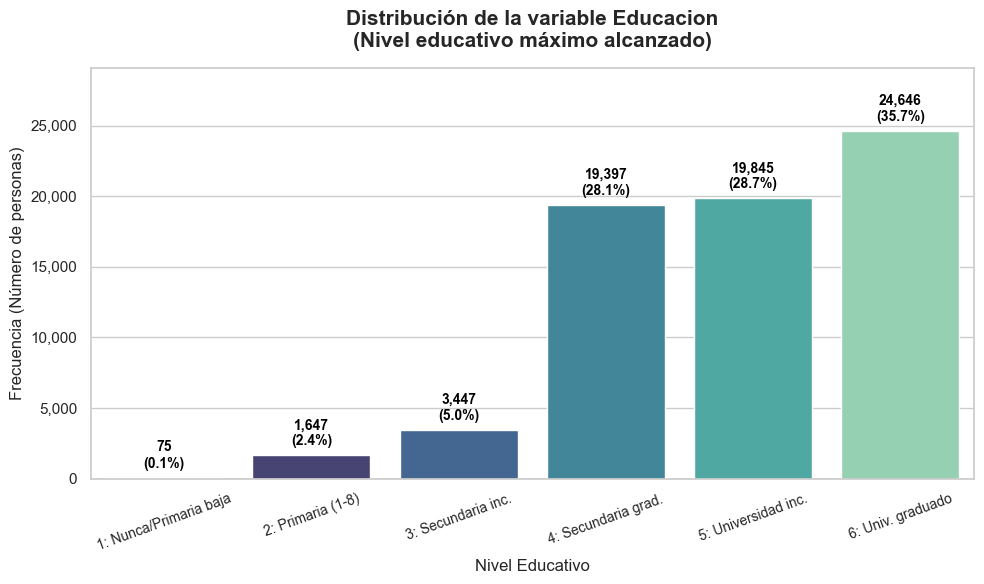

In [58]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

etiquetas_educacion = [
    '1: Nunca/Primaria baja',
    '2: Primaria (1-8)',
    '3: Secundaria inc.',
    '4: Secundaria grad.',
    '5: Universidad inc.',
    '6: Univ. graduado'
]

ax = sns.barplot(data=tabla_educacion, x='Educacion', y='Frecuencia', palette='mako')

plt.title('Distribución de la variable Educacion\n(Nivel educativo máximo alcanzado)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nivel Educativo', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=range(6), labels=etiquetas_educacion, rotation=20, fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    pct = tabla_educacion['Porcentaje'].iloc[i]
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_educacion['Frecuencia'].max() * 1.18)
plt.tight_layout()
plt.show()

La mayoria de personas encuestadas completaron al menos la secundaria mientras que unos pocos tienen un nivel educativo inferior a secundaria. 

(`Ingresos`): Esta variable está codificada en una escala ordinal de 8 niveles basados en los ingresos familiares totales anuales (antes de impuestos).

**Tabla**

In [ ]:
tabla_ingresos = (
    df['Ingresos']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Ingresos': 'Ingresos', 'count': 'Frecuencia'})
)
tabla_ingresos['Porcentaje'] = (tabla_ingresos['Frecuencia'] / tabla_ingresos['Frecuencia'].sum() * 100).round(1)

print("Tabla de Frecuencias de Ingresos:")
print(tabla_ingresos)

**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


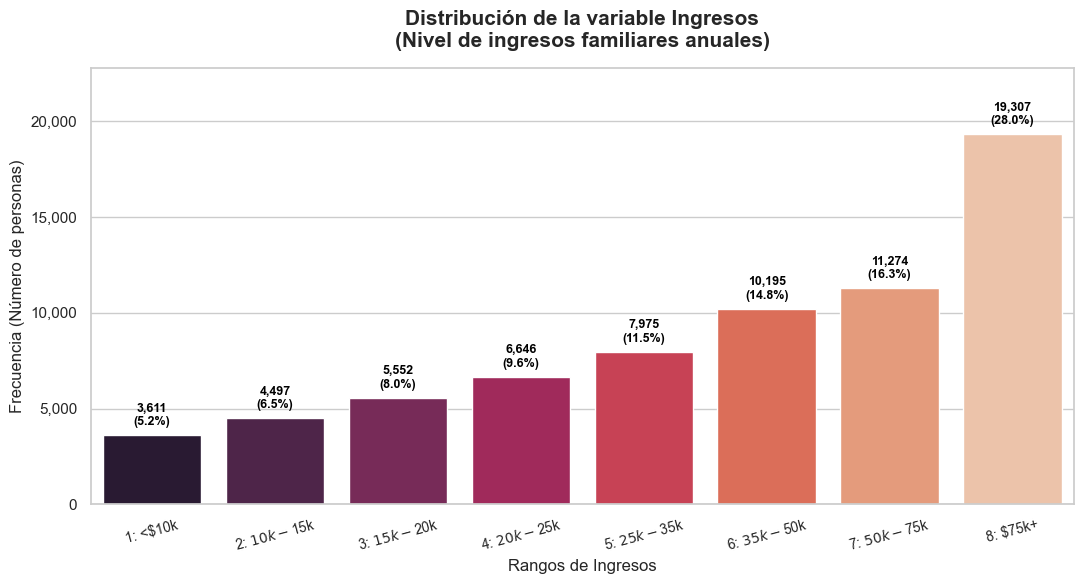

In [60]:
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

etiquetas_ingresos = [
    '1: <$10k',
    '2: $10k-$15k',
    '3: $15k-$20k',
    '4: $20k-$25k',
    '5: $25k-$35k',
    '6: $35k-$50k',
    '7: $50k-$75k',
    '8: $75k+'
]

ax = sns.barplot(data=tabla_ingresos, x='Ingresos', y='Frecuencia', palette='rocket')

plt.title('Distribución de la variable Ingresos\n(Nivel de ingresos familiares anuales)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rangos de Ingresos', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(ticks=range(8), labels=etiquetas_ingresos, rotation=15, fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i, p in enumerate(ax.patches):
    pct = tabla_ingresos['Porcentaje'].iloc[i]
    ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, tabla_ingresos['Frecuencia'].max() * 1.18)
plt.tight_layout()
plt.show()

Podemos ver que la mayoria de personas encuestadas cuentan con ingresos anuales superiores a 25k$, gran parte de los encuestados ganando mas de 75k$. Por otro lado hay menos personas ganando por debajo de los 25k$, siendo muy poco el porcentaje de gente que gana menos de 10k$. 

## 3. Variables Numericas

(`IMC`): esta variable indica el indice de masa corporal del paciente. 

**Tabla**

In [ ]:

promedio = df['IMC'].mean()
minimo = df['IMC'].min()
maximo = df['IMC'].max()

q1 = df['IMC'].quantile(0.25)
q3 = df['IMC'].quantile(0.75)
rango_intercuartil = q3 - q1

tabla_imc = pd.DataFrame({
    'Estadística': ['Promedio', 'Rango Intercuartil (IQR)', 'Mínimo', 'Máximo'],
    'Valor': [round(promedio, 2), rango_intercuartil, minimo, maximo]
})

print(tabla_imc)

**Grafico**

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.histplot(data=df, x='IMC', bins=40, kde=True, color='#3498db')

plt.title('Distribución (Histograma) de la variable IMC', fontsize=15, fontweight='bold')
plt.xlabel('Índice de Masa Corporal (IMC)', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)

plt.tight_layout()
plt.show()

 Como podemos ver, la distribución no es una campana simétrica perfecta. Tiene una "cola" larga que se extiende hacia la derecha. Esto se debe a los valores atípicos (outliers) de IMC muy altos (personas con obesidad severa, llegando hasta 98.0) que vimos en el diagrama de caja anterior.
 La gran mayoría de las personas se concentran en el rango de un IMC entre 25.0 y 30.0, lo cual coincide con el rango de sobrepeso según las categorías médicas estándar. El punto más alto del histograma ocurre justo en este rango.

(`SaludM`): Mide el número de días (de 0 a 30) en los que la salud mental de la persona no fue buena durante los últimos 30 días.

**Tabla**

In [ ]:
promedio = df['SaludM'].mean()
minimo = df['SaludM'].min()
maximo = df['SaludM'].max()
q1 = df['SaludM'].quantile(0.25)
q3 = df['SaludM'].quantile(0.75)
iqr = q3 - q1

tabla_stats_saludm = pd.DataFrame({
    'Estadística': ['Promedio', 'Rango Intercuartil (IQR)', 'Mínimo', 'Máximo'],
    'Valor': [round(promedio, 2), f"{iqr} (Q1: {q1}, Q3: {q3})", minimo, maximo]
})
print(tabla_stats_saludm)

**Grafico**

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.boxplot(x=df['SaludM'], color='#e74c3c')

plt.title('Diagrama de Cajas y Bigotes para la variable SaludM\n(Días con mala salud mental en los últimos 30 días)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de días (0 a 30)', fontsize=12)

plt.tight_layout()
plt.show()

Como se ve en el IQR, el 75% de las personas reportan haber tenido 2 días o menos de mala salud mental al mes (y una gran mayoría reporta exactamente 0 días). Sin embargo, existen valores atípicos (outliers) que alcanzan hasta los 30 días completos.

(`SaludF`): Mide el número de días (de 0 a 30) en los que la salud física del encuestado no fue buena durante los últimos 30 días.

**Tabla**

In [48]:
promedio = df['SaludF'].mean()
minimo = df['SaludF'].min()
maximo = df['SaludF'].max()
q1 = df['SaludF'].quantile(0.25)
q3 = df['SaludF'].quantile(0.75)
iqr = q3 - q1

tabla_stats_saludf = pd.DataFrame({
    'Estadística': ['Promedio', 'Rango Intercuartil (IQR)', 'Mínimo', 'Máximo'],
    'Valor': [round(promedio, 2), f"{iqr} (Q1: {q1}, Q3: {q3})", minimo, maximo]
})
print(tabla_stats_saludf)

                Estadística                   Valor
0                  Promedio                    5.95
1  Rango Intercuartil (IQR)  6.0 (Q1: 0.0, Q3: 6.0)
2                    Mínimo                     0.0
3                    Máximo                    30.0


**Grafico**

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.boxplot(x=df['SaludF'], color='#2980b9')

plt.title('Diagrama de Cajas y Bigotes para la variable SaludF\n(Días con mala salud física en los últimos 30 días)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de días (0 a 30)', fontsize=12)

plt.tight_layout()
plt.show()

El promedio de días con mala salud física es ligeramente mayor (5.81 días frente a 3.75). El rango intercuartil indica que el 75% central de las personas reportan tener 6 días o menos de malestar físico al mes, aunque encontramos valores extremos que llegan hasta los 30 días completos.